In [1]:
import pandas as pd
import geopandas as gpd
import fiona
import numpy as np
import requests

In [2]:
calfire = gpd.read_file('California_Fire_Perimeters_(all).shp')

/opt/miniconda3/envs/burnseverity/lib/python3.13/site-packages/pyogrio/raw.py:198: RuntimeWarning: California_Fire_Perimeters_(all).shp contains polygon(s) with rings with invalid winding order. Autocorrecting them, but that shapefile should be corrected using ogr2ogr for example.
  return ogr_read(


In [ ]:
calfire_filtered = calfire[(calfire['YEAR_'] > 2015) & (calfire['AGENCY'] == 'NPS')].copy()
unique_parks = calfire_filtered['UNIT_ID'].unique()

array(['KNP', 'YNP', 'PIP', 'MNP', 'JTP', 'RWP', 'BNP', 'RNP', 'CNP',
       'SMP', 'GNP', 'LNP'], dtype=object)

UNIT_ID
KNP    20
MNP    12
SMP     7
JTP     2
CNP     2
Name: count, dtype: int64


/opt/miniconda3/envs/burnseverity/lib/python3.13/site-packages/pyogrio/raw.py:723: RuntimeWarning: Field ALARM_DATE created as String field, though DateTime requested.
  ogr_write(
/opt/miniconda3/envs/burnseverity/lib/python3.13/site-packages/pyogrio/raw.py:723: RuntimeWarning: Field CONT_DATE created as String field, though DateTime requested.
  ogr_write(


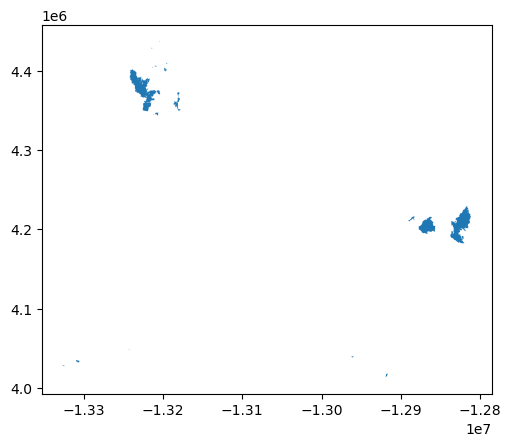

In [22]:
parks = ['JTP', 'MNP', 'KNP', 'CNP', 'SMP']
calfire_filtered_parks = calfire_filtered[(calfire_filtered['UNIT_ID'].isin(parks))].copy()
print(calfire_filtered_parks['UNIT_ID'].value_counts())
calfire_filtered_parks.plot()
calfire_filtered_parks.to_file('Validation_Fire_Perimeters_2015_2024.shp')

           minx       miny        maxx       maxy
554 -115.326399  35.131053 -115.086283  35.478399


/opt/miniconda3/envs/burnseverity/lib/python3.13/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(


np.datetime64('2023-07-28T00:00:00.000')

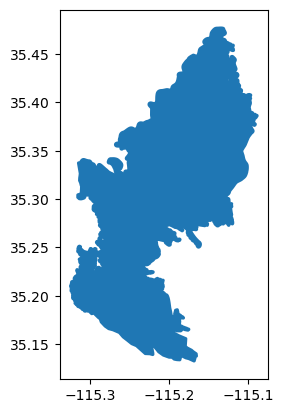

In [ ]:
def create_bbox(fire_name, fires):
    ''' creates a buffered bounding box around a fire parameter '''

    fire = fires[fires['FIRE_NAME'] == fire_name].buffer(250).to_crs(epsg=4326)
    
    bbox = fire.bounds

    return bbox

def get_fire_date(fire_name, fires):
    ''' gets the start date of a fire '''

    start_date = fires[fires['FIRE_NAME'] == fire_name]['ALARM_DATE'].values[0]

    return start_date

create_bbox('YORK', calfire_filtered_parks)
get_fire_date('YORK', calfire_filtered_parks)


In [ ]:
def create_query(fire_name, bbox, date_of_fire, post_fire_range):
    ''' Creates an API qury for the bounding box and time period specified '''

    pre_start = date_of_fire - np.timedelta64(21, 'D')
    pre_end = date_of_fire - np.timedelta64(1, 'D')
    post_end = date_of_fire + np.timedelta64(post_fire_range, 'D')

    api_request = {
        # add date to fire name
        "fire_event_name": f"{fire_name}_date{str(date_of_fire).split('T')[0]}_range{post_fire_range}",
        "coarse_geojson": {
            "type": "Polygon",
            "coordinates": [[
                [float(bbox[0]), float(bbox[1])], 
                [float(bbox[2]), float(bbox[1])],
                [float(bbox[2]), float(bbox[3])], 
                [float(bbox[0]), float(bbox[3])], 
                [float(bbox[0]), float(bbox[1])]  
            ]]
        },
        "prefire_date_range": [str(pre_start).split('T')[0], str(pre_end).split('T')[0]],
        "postfire_date_range": [str(date_of_fire).split('T')[0], str(post_end).split('T')[0]]
    }
   
    return api_request

    

/opt/miniconda3/envs/burnseverity/lib/python3.13/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(


<Axes: >

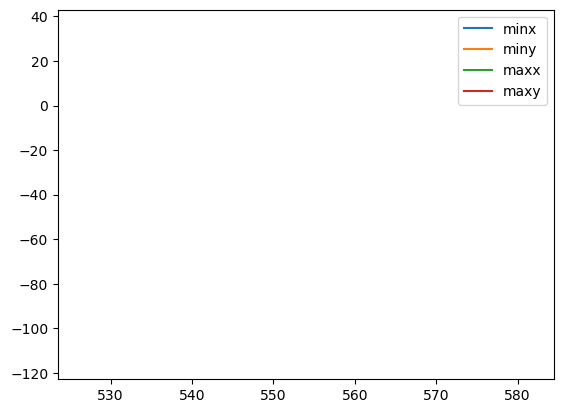

In [ ]:
fire_name = 'YORK'
bbox = create_bbox(fire_name, calfire_filtered_parks)
date_of_fire = get_fire_date(fire_name, calfire_filtered_parks)



#create_query(fire_name, bbox.values[0], date_of_fire, 15)

In [53]:
url = "https://fire-recovery-backend-dev-113009620257.us-central1.run.app/fire-recovery/process/analyze_fire_severity" 
query_data = create_query(fire_name, bbox.values[0], date_of_fire, 15)
try:
    # Use the 'json' parameter: it automatically sets 'Content-Type: application/json'
    # and runs json.dumps() for you.
    response = requests.post(url, json=query_data)

    # 4. Check the results
    if response.status_code == 200 or response.status_code == 201:
        print("Success!")
        print(response.json()) # This is the data the API sends back
    else:
        print(f"Failed with status code: {response.status_code}")
        print(response.text) # This shows the error message from the API

except requests.exceptions.RequestException as e:
    print(f"A connection error occurred: {e}")

Success!
{'fire_event_name': 'YORK_2023-07-28_15', 'status': 'Processing started', 'job_id': '36404947-7622-42ed-b8b6-b4b8e6fb9b0a'}


In [56]:
# Get list of fire names to process
fire_names = calfire_filtered_parks['FIRE_NAME'].unique()

# Define post-fire day ranges to test
post_fire_days = [5, 10, 15, 21, 30, 45, 60, 90]

# Initialize list to collect results
results = []

url = "https://fire-recovery-backend-dev-113009620257.us-central1.run.app/fire-recovery/process/analyze_fire_severity"

# Loop through each fire and post-fire day range
for fire_name in fire_names:
    bbox = create_bbox(fire_name, calfire_filtered_parks)
    date_of_fire = get_fire_date(fire_name, calfire_filtered_parks)
    
    for post_fire_range in post_fire_days:
        query_data = create_query(fire_name, bbox.values[0], date_of_fire, post_fire_range)
        
        try:
            response = requests.post(url, json=query_data)
            
            if response.status_code == 200 or response.status_code == 201:
                response_data = response.json()
                results.append({
                    'fire_event_name': response_data.get('fire_event_name'),
                    'job_id': response_data.get('job_id'),
                    'fire_name': fire_name,
                    'post_fire_days': post_fire_range,
                    'status': 'success'
                })
                print(f"✓ {fire_name} ({post_fire_range} days): {response_data.get('job_id')}")
            else:
                results.append({
                    'fire_event_name': None,
                    'job_id': None,
                    'fire_name': fire_name,
                    'post_fire_days': post_fire_range,
                    'status': f'failed_{response.status_code}'
                })
                print(f"✗ {fire_name} ({post_fire_range} days): Failed with {response.status_code}")
                
        except requests.exceptions.RequestException as e:
            results.append({
                'fire_event_name': None,
                'job_id': None,
                'fire_name': fire_name,
                'post_fire_days': post_fire_range,
                'status': f'error'
            })
            print(f"✗ {fire_name} ({post_fire_range} days): Connection error")

# Create dataframe and save to CSV
df_results = pd.DataFrame(results)
df_results.to_csv('fire_processing_jobs.csv', index=False)

print(f"\nProcessed {len(results)} requests. Results saved to fire_processing_jobs.csv")
display(df_results)

/opt/miniconda3/envs/burnseverity/lib/python3.13/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(


✓ COFFEE POT (5 days): 573421be-412c-403d-9d72-b591de886c43
✓ COFFEE POT (10 days): eb5075d7-06b1-401d-9aa5-ba94efebc8e0
✓ COFFEE POT (15 days): 743d5692-aafc-4230-9e57-f9db89bade40
✓ COFFEE POT (21 days): 83abcfa3-75c4-4350-855d-12c4af526810
✓ COFFEE POT (30 days): a269a19f-a8ee-49e7-80d9-836497cf96fe
✓ COFFEE POT (45 days): 0e885e28-4994-4b3a-9e58-89786837ac37
✓ COFFEE POT (60 days): a78457b1-bbe0-4ebf-aa29-710c5e18885e
✓ COFFEE POT (90 days): dd0065d0-cb5e-4d86-94bb-1e28bb6eb510


/opt/miniconda3/envs/burnseverity/lib/python3.13/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(


✓ SENTINEL (5 days): 341a7fbb-517c-4e7a-aefc-fb5fdd5e9e4d
✓ SENTINEL (10 days): 1523d5ba-6894-4f52-b769-f3d18fcb01b0
✓ SENTINEL (15 days): cf296422-5771-4189-bcff-e6502214e79d
✓ SENTINEL (21 days): 672dbb6f-2e37-4e5c-a6f4-f0cc28189784
✓ SENTINEL (30 days): 693d29ca-35d0-4144-bfdd-284de0b66cdc
✓ SENTINEL (45 days): 76a189b9-7204-4a19-bc45-e2d9fee7a06a
✓ SENTINEL (60 days): d47a7707-5026-4220-8c37-d97c8e4264c7
✓ SENTINEL (90 days): d086d61f-8a22-4c2c-a0c7-2991e76ee9e3


/opt/miniconda3/envs/burnseverity/lib/python3.13/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(


...

/opt/miniconda3/envs/burnseverity/lib/python3.13/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(


✓ MULHOLLAND (5 days): d1659057-8866-4a94-8f5d-a152f3872394
✓ MULHOLLAND (10 days): cda08732-9648-44c8-b11d-15cf7e7fe1da
✓ MULHOLLAND (15 days): 59c0e205-b7b0-4ed6-a9dc-335d3d949dc3
✓ MULHOLLAND (21 days): eeda15b3-d9c7-4f41-9a6f-53c8c187cc1f
✓ MULHOLLAND (30 days): 327102ff-9c0e-4ba0-b9e3-320139b669e7
✓ MULHOLLAND (45 days): eb53eb5f-bf81-48ea-bc8b-2d78095c95c2
✓ MULHOLLAND (60 days): 1dc0eb89-f043-4c2a-a384-0159d737405f
✓ MULHOLLAND (90 days): 1b6189ed-cfe9-44c2-91da-15f1c36d4f0b


/opt/miniconda3/envs/burnseverity/lib/python3.13/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(


✓ COAST (5 days): edb3802e-83f5-4536-a1f7-a3e7f7e1bf64
✓ COAST (10 days): c320f31d-edcd-4485-8a9a-010271aa73af
✓ COAST (15 days): be18b112-6f06-42b0-8f0f-a2b974d3d6e3
✓ COAST (21 days): 6190d020-e0bb-49d6-ac96-a9c22aa74edb
✓ COAST (30 days): 7b77efce-2d54-44b8-817b-ccb11be87e53
✓ COAST (45 days): 9df2e66a-d85e-4b9f-88d6-50101199a8f3
✓ COAST (60 days): a77aa094-bd6c-4b2e-ab7c-7179a23d5d00
✓ COAST (90 days): d22295b8-0e4c-4f14-a568-4fc44abb7266
✓ LIBERTY CANYON (5 days): cd54916b-3913-4b0c-a72b-ecdda1167f7b
✓ LIBERTY CANYON (10 days): a698995d-afd4-4c13-b70b-a7147aa0f8b9
✓ LIBERTY CANYON (15 days): 70909577-0502-49e3-8e93-7446151eb32d
✓ LIBERTY CANYON (21 days): bc3d5e99-a7e4-4488-a092-04a0df1fc0b2
✓ LIBERTY CANYON (30 days): 49f3b8c1-c577-44a2-bdfc-740b1317a557
✓ LIBERTY CANYON (45 days): cac865be-7853-4609-a9e3-ff4904a8888c
✓ LIBERTY CANYON (60 days): f92febfb-6aa7-4aaa-a283-33d25ec3e39f
✓ LIBERTY CANYON (90 days): 50f98997-4bcd-4063-bb07-4d99e7a78f12


NameError: name 'pd' is not defined

In [57]:
import pandas as pd
df_results = pd.DataFrame(results)
df_results.to_csv('fire_processing_jobs.csv', index=False)

print(f"\nProcessed {len(results)} requests. Results saved to fire_processing_jobs.csv")
display(df_results)



Processed 328 requests. Results saved to fire_processing_jobs.csv


,fire_event_name,job_id,fire_name,post_fire_days,status
0,COFFEE POT_2024-08-03_5,573421be-412c-403d-9d72-b591de886c43,COFFEE POT,5,success
1,COFFEE POT_2024-08-03_10,eb5075d7-06b1-401d-9aa5-ba94efebc8e0,COFFEE POT,10,success
2,COFFEE POT_2024-08-03_15,743d5692-aafc-4230-9e57-f9db89bade40,COFFEE POT,15,success
3,COFFEE POT_2024-08-03_21,83abcfa3-75c4-4350-855d-12c4af526810,COFFEE POT,21,success
4,COFFEE POT_2024-08-03_30,a269a19f-a8ee-49e7-80d9-836497cf96fe,COFFEE POT,30,success
...,...,...,...,...,...
323,LIBERTY CANYON_2016-11-05_21,bc3d5e99-a7e4-4488-a092-04a0df1fc0b2,LIBERTY CANYON,21,success
324,LIBERTY CANYON_2016-11-05_30,49f3b8c1-c577-44a2-bdfc-740b1317a557,LIBERTY CANYON,30,success
325,LIBERTY CANYON_2016-11-05_45,cac865be-7853-4609-a9e3-ff4904a8888c,LIBERTY CANYON,45,success
326,LIBERTY CANYON_2016-11-05_60,f92febfb-6aa7-4aaa-a283-33d25ec3e39f,LIBERTY CANYON,60,success
